# Predictive Analysis for a Retail Store

### Objective
Your task is to develop a predictive model for a retail store that wants to forecast sales based on various features. The store has been collecting data on daily sales and wants to use this information to make informed decisions about inventory management, promotions, and staff scheduling.

Your goal is to build a model that can predict the total sales for the upcoming month, using data from previous months.


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier


### Task
**1. Data Preparation**  
- Load the dataset and perform any necessary preprocessing, such as handling **missing values**, selecting **dependent and independent variables**, and splitting the data into **training** and **testing** sets.


In [2]:
df = pd.read_csv("Sales.csv")
df.head()

,Fecha,DíaDeLaSemana,Promociones,Festivo,Ventas
0,2022-01-01,6,0,0,4033
1,2022-01-02,7,0,1,4012
2,2022-01-03,1,0,0,1608
3,2022-01-04,2,1,0,2046
4,2022-01-05,3,0,0,2484


In [3]:
df.rename(columns={
    'Fecha':'Date',
    'DíaDeLaSemana':'DayOfWeek',
    'Promociones':'Promotions',
    'Festivo':'Holiday',
    'Ventas':'Sales'

}, inplace=True)

**2. Exploratory Data Analysis (EDA)**  
- Perform an EDA to understand the distribution of sales and the relationships between sales and other variables.  
  This may include plotting sales over time, analyzing sales on *holidays* vs. *non-holidays*, and evaluating the impact of promotions.


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 365 entries, 0 to 364
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Date        365 non-null    object
 1   DayOfWeek   365 non-null    int64 
 2   Promotions  365 non-null    int64 
 3   Holiday     365 non-null    int64 
 4   Sales       365 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 14.4+ KB


In [5]:
df['Date'] = pd.to_datetime(df['Date'])

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 365 entries, 0 to 364
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   Date        365 non-null    datetime64[ns]
 1   DayOfWeek   365 non-null    int64         
 2   Promotions  365 non-null    int64         
 3   Holiday     365 non-null    int64         
 4   Sales       365 non-null    int64         
dtypes: datetime64[ns](1), int64(4)
memory usage: 14.4 KB


In [7]:
df.describe()

,Date,DayOfWeek,Promotions,Holiday,Sales
count,365,365.000000,365.000000,365.000000,365.000000
mean,2022-07-01 23:59:59.999999744,4.005479,0.200000,0.142466,2997.219178
min,2022-01-01 00:00:00,1.000000,0.000000,0.000000,1305.000000
25%,2022-04-02 00:00:00,2.000000,0.000000,0.000000,2195.000000
50%,2022-07-02 00:00:00,4.000000,0.000000,0.000000,3074.000000
75%,2022-10-01 00:00:00,6.000000,0.000000,0.000000,3979.000000
max,2022-12-31 00:00:00,7.000000,1.000000,1.000000,4404.000000
std,NaN,2.002738,0.400549,0.350007,942.096284


In [8]:
escala = MinMaxScaler(feature_range=(0,1))
columnas_para_escalar = df.drop(['Sales', 'Date'],axis=1).columns
normado = escala.fit_transform(df[columnas_para_escalar])
df_normado = pd.DataFrame(data=normado, columns=columnas_para_escalar)

df_normado['Sales'] = df['Sales']
df_normado['Date'] = df['Date']


In [9]:
df_normado.head()

,DayOfWeek,Promotions,Holiday,Sales,Date
0,0.833333,0.0,0.0,4033,2022-01-01
1,1.000000,0.0,1.0,4012,2022-01-02
2,0.000000,0.0,0.0,1608,2022-01-03
3,0.166667,1.0,0.0,2046,2022-01-04
4,0.333333,0.0,0.0,2484,2022-01-05


In [10]:
X = df_normado.drop(['Sales', 'Date'], axis=1)

In [11]:
y=df_normado['Sales']

In [12]:
X_train, X_test, y_train, y_test = train_test_split(X,y, train_size=0.8, random_state=42)

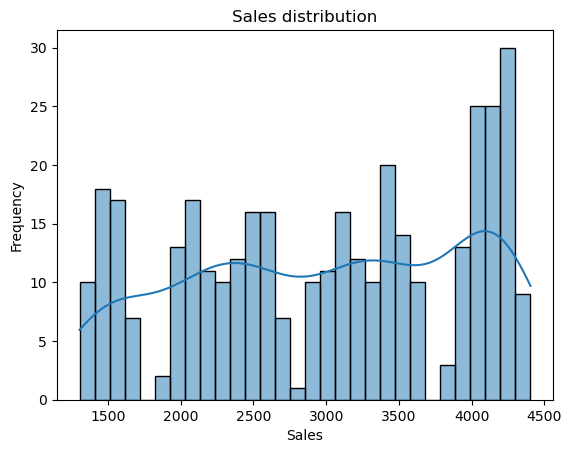

In [13]:
plt.Figure(figsize=(12,6))
sns.histplot(df['Sales'], bins=30, kde=True)
plt.title('Sales distribution')
plt.xlabel('Sales')
plt.ylabel('Frequency');

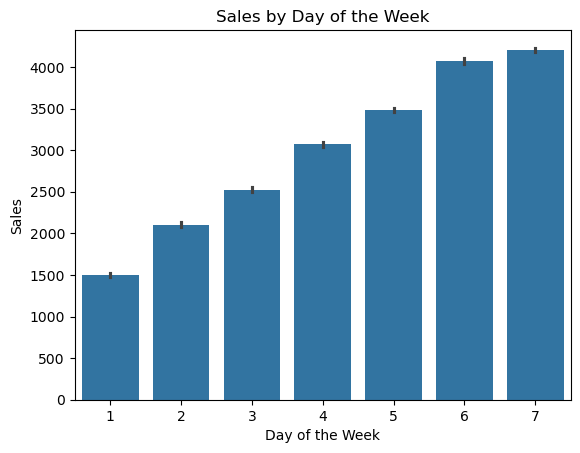

In [14]:
plt.Figure(figsize=(12,6))
sns.barplot(data=df,x='DayOfWeek', y='Sales')
plt.title('Sales by Day of the Week')
plt.xlabel('Day of the Week')
plt.ylabel('Sales');

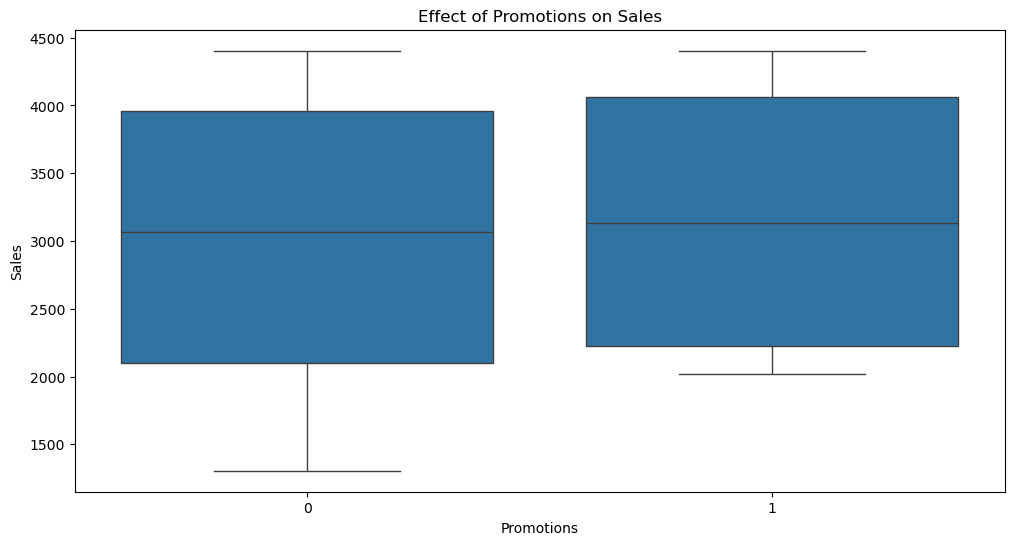

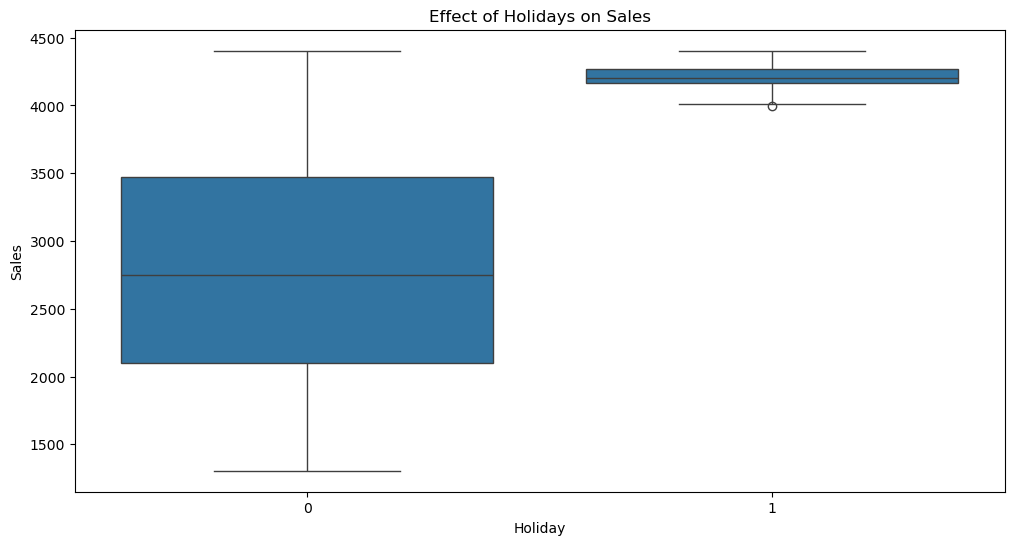

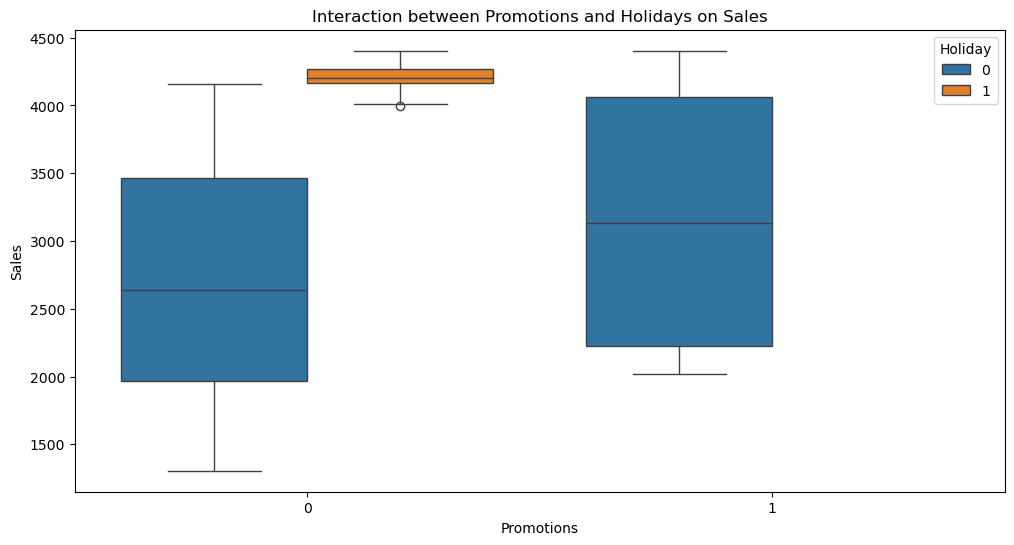

In [15]:

# boxplot to compare sales with and without promotions.
plt.figure(figsize=(12, 6))
sns.boxplot(x='Promotions', y='Sales', data=df)
plt.title('Effect of Promotions on Sales')

# boxplot to compare sales for regular and holiday days.
plt.figure(figsize=(12, 6))
sns.boxplot(x='Holiday', y='Sales', data=df)
plt.title('Effect of Holidays on Sales')

# boxplot to see the interaction between promotions and holidays on sales.
plt.figure(figsize=(12, 6))
sns.boxplot(x='Promotions', y='Sales', hue='Holiday', data=df)
plt.title('Interaction between Promotions and Holidays on Sales');



**3. Model Selection**  
- Use your knowledge of different algorithms to choose the most suitable model for this task.  
  Consider **Linear Regression**, **Decision Trees**, and **Random Forests**.

In [16]:
models = [
    ('Linear Regression Model', LinearRegression()),
    ('Decission Tree Model', DecisionTreeClassifier(random_state=42)),
    ('Random Forest Model', RandomForestClassifier(random_state=42))
]

In [17]:
for name, model in models:
    model.fit(X_train, y_train)
    score = model.score(X_test, y_test)
    print(f"{name}: {score}")

Linear Regression Model: 0.9924245101323563
Decission Tree Model: 0.0
Random Forest Model: 0.0136986301369863


**4. Model Training and Evaluation**  
- Train your selected model on the training set and evaluate its performance on the test set.  
  Use visualizations to compare *actual* vs. *predicted* sales.

In [18]:
# We observe that the best model for this case is Linear Regression
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)
linear_predictions = linear_model.predict(X_test)

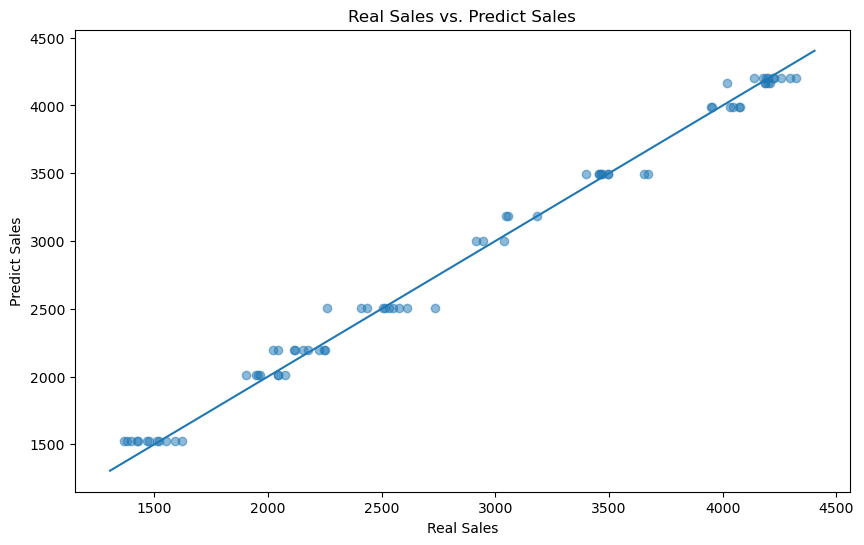

In [19]:
plt.figure(figsize=(10,6))
plt.scatter(y_test, linear_predictions, alpha=0.5)
plt.plot([y.min(), y.max()], [y.min(), y.max()]);
plt.title("Real Sales vs. Predict Sales")
plt.xlabel("Real Sales")
plt.ylabel("Predict Sales");


In [20]:
df_test=pd.DataFrame({'Real':y_test, 'Predict':linear_predictions})
df_test=df_test.sort_index()
df_test

,Real,Predict
0,4033,3986.386872
3,2046,2195.645597
5,3046,3181.550163
9,1381,1521.625458
15,4176,4201.069767
...,...,...
347,2515,2507.530023
349,3670,3493.434589
352,1519,1521.625458
359,1398,1521.625458


Text(0.5, 1.0, 'Comparison of Actual and Predicted Sales Over Time')

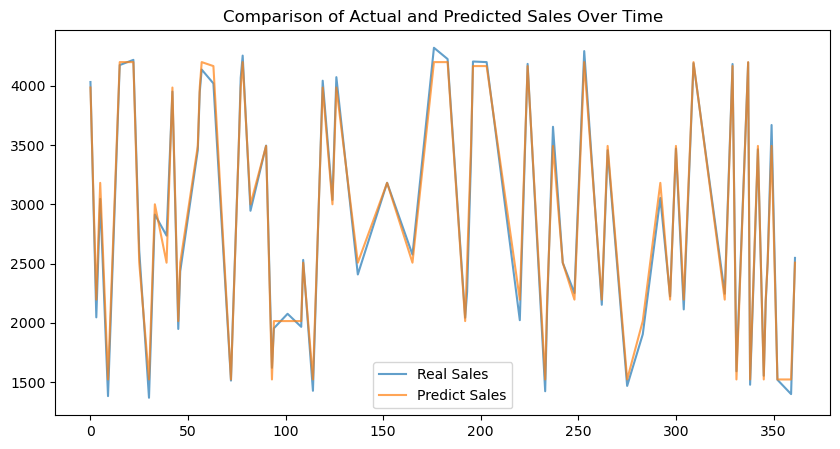

In [21]:
plt.figure(figsize=(10,5))
plt.plot(df_test['Real'], label="Real Sales", alpha=0.7)
plt.plot(df_test['Predict'], label='Predict Sales', alpha=0.7)
plt.legend()
plt.title('Comparison of Actual and Predicted Sales Over Time')

**5. Conclusion**

The first chart, which shows a scatter plot of Actual Sales vs. Predicted Sales, suggests that the linear regression model is doing a good job of predicting sales. The trend line indicates a strong positive relationship between the actual and predicted values, which is a promising sign that the model can effectively capture the sales trend.

The second chart compares Actual Sales and Predicted Sales over time and also appears to follow a similar pattern, although there are some points where the predictions and actual values differ significantly. This could be due to events not captured by the variables in your model or natural variations in sales that are not predictable.

Here are some recommendations for the retail store:

*   **Inventory Optimization:** Use the predictions to better manage inventory. Holiday dates may require additional stock to avoid product shortages.
*   **Staff Scheduling:** Adjust staff schedules based on holidays, and not necessarily on promotion days.
*   **Targeted Marketing:** If you identify patterns of when sales are strongest, you can target marketing campaigns for those periods and potentially increase sales even further.
*   **Anomaly Analysis:** Investigate those points where there are large deviations between actual and predicted sales to better understand the factors not captured by the model.
*   **Model Improvements:** Consider including more variables in the model that could affect sales, such as general economic data, local events, competition, or even weather.